# On-device quantized LLM — Qwen2.5-0.5B on Snapdragon via Qualcomm AI Hub

Pipeline for quantizing Qwen2.5-0.5B across bit-widths, measuring quality,
and profiling on a **real Snapdragon 8 Gen 3 NPU** via Qualcomm AI Hub.
.


## Phase 0 — Setup

In [3]:
!pip install -q -U transformers accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 108.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 45.1 MB/s eta 0:00:00


In [4]:
import os
for d in ["src/baseline","src/eval","src/quantize","src/deploy","src/viz","results"]:
    os.makedirs(f"/kaggle/working/llm-edge-quant/{d}", exist_ok=True)
os.chdir("/kaggle/working/llm-edge-quant")          # all relative paths (results/) resolve here
print("cwd:", os.getcwd())

cwd: /kaggle/working/llm-edge-quant


In [5]:
from huggingface_hub import snapshot_download
snapshot_download("Qwen/Qwen2.5-0.5B-Instruct", local_dir="/kaggle/working/qwen2.5-0.5b-instruct")
print("model ready")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

model ready


## Phase 1 — FP16 baseline (perplexity + generations)

In [7]:
%%writefile /kaggle/working/llm-edge-quant/src/baseline/baseline.py
"""Phase 1  — FP16 baseline for Qwen2.5-0.5B-Instruct.

Measures the reference numbers every quantized model is later compared against:
  - parameter count + FP16 weight size
  - WikiText-2 perplexity (fluency anchor)
  - 3 qualitative generations (saved to results/generations_fp16.md)

Loads from a local Kaggle dataset snapshot if one is attached, else downloads
from Hugging Face. Appends measured numbers to results/metrics.csv.

python src/baseline/baseline.py
"""
import os, csv, glob, torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"        
RESULTS    = "results/metrics.csv"

# Prefer a local snapshot dataset; fall back to HF download.
_hits = glob.glob("/kaggle/input/qwen25-05b-instruct/**/config.json", recursive=True)
MODEL_PATH = os.path.dirname(_hits[0]) if _hits else MODEL_NAME
if _hits:
    os.environ["HF_HUB_OFFLINE"] = "1"
print(f"loading from: {MODEL_PATH}")


def log_metric(precision, metric, value, note=""):
    os.makedirs("results", exist_ok=True)
    new = not os.path.exists(RESULTS)
    with open(RESULTS, "a", newline="") as f:
        w = csv.writer(f)
        if new: w.writerow(["model", "precision", "metric", "value", "note"])
        w.writerow([MODEL_NAME, precision, metric, value, note])   # log NAME, not path


def load(device):
    tok = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, dtype=torch.float16).to(device).eval()
    return tok, model


@torch.no_grad()
def qualitative(tok, model, device):
    prompts = [
        "Explain what a KV cache is in one paragraph.",
        "Give me three tips for reducing LLM inference latency on a phone.",
        "Write a short poem about quantization.",
    ]
    os.makedirs("results", exist_ok=True)
    with open("results/generations_fp16.md", "w") as fout:
        for p in prompts:
            inputs = tok.apply_chat_template(
                [{"role": "user", "content": p}],
                add_generation_prompt=True, return_tensors="pt", return_dict=True,
            ).to(device)
            gen = model.generate(**inputs, max_new_tokens=200, do_sample=False)  # greedy = reproducible
            text = tok.decode(gen[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            print(f"\n=== {p}\n{text}")
            fout.write(f"### {p}\n\n{text}\n\n")


@torch.no_grad()
def perplexity(tok, model, device, max_length=2048, stride=1024):
    ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
    ids = tok("\n\n".join(ds["text"]), return_tensors="pt").input_ids.to(device)
    seq_len, nlls, prev = ids.size(1), [], 0
    for begin in range(0, seq_len, stride):
        end = min(begin + max_length, seq_len)
        trg = end - prev
        chunk = ids[:, begin:end]
        target = chunk.clone(); target[:, :-trg] = -100   # score only the new tokens
        loss = model(chunk, labels=target).loss
        nlls.append(loss.float() * trg); prev = end
        if end == seq_len: break
    return torch.exp(torch.stack(nlls).sum() / end).item()


def main():
    device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    print("device:", device)
    tok, model = load(device)

    n = sum(p.numel() for p in model.parameters())
    print(f"params: {n/1e6:.1f} M  ->  FP16 weights ~ {n*2/1e9:.2f} GB")
    log_metric("fp16", "params_millions", round(n / 1e6, 1))
    log_metric("fp16", "weights_gb_fp16", round(n * 2 / 1e9, 3))

    qualitative(tok, model, device)
    ppl = perplexity(tok, model, device)
    print(f"\nWikiText-2 perplexity (fp16, win2048/stride1024): {ppl:.3f}")
    log_metric("fp16", "wikitext2_ppl", round(ppl, 3), "win2048_stride1024")


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/llm-edge-quant/src/baseline/baseline.py


In [8]:
!python src/baseline/baseline.py

loading from: Qwen/Qwen2.5-0.5B-Instruct
device: cuda
config.json: 100%|█████████████████████████████| 659/659 [00:00<00:00, 1.83MB/s]
tokenizer_config.json: 100%|███████████████| 7.30k/7.30k [00:00<00:00, 17.5MB/s]
vocab.json: 100%|███████████████████████████| 2.78M/2.78M [00:00<00:00, 117MB/s]
merges.txt: 100%|███████████████████████████| 1.67M/1.67M [00:00<00:00, 123MB/s]
tokenizer.json: 100%|███████████████████████| 7.03M/7.03M [00:00<00:00, 149MB/s]

model.safetensors: downloading bytes: ▋                     | 29.6MB            
model.safetensors: downloading bytes: ██▍                   |  111MB, 6.59MB/s  
model.safetensors: downloading bytes: ████████              |  360MB, 27.7MB/s  
model.safetensors: reconstructing file:  27%|█▋    |  268MB /  988MB, 12.8MB/s  
model.safetensors: downloading bytes: ██████████▎           |  464MB, 38.1MB/s  
model.safetensors: downloading bytes: ███████████████▉      |  716MB, 59.1MB/s  
model.safetensors: reconstructing file:  68%|████  |  

## Phase 1b — HellaSwag accuracy

In [9]:
%%writefile /kaggle/working/llm-edge-quant/src/eval/hellaswag.py
"""Phase 1b  — HellaSwag acc_norm for the HF (FP16) model.

Custom length-normalized log-likelihood scorer over the 4 endings.
Internally consistent across bit-widths (valid for measuring degradation);
NOT directly comparable to lm-eval-harness leaderboard numbers.
Reproduces the published ~0.49 for Qwen2.5-0.5B, which validates the scorer.

Run (from repo root):  python src/eval/hellaswag.py --n 1000
"""
import os, csv, glob, argparse, torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
RESULTS = "results/metrics.csv"
_hits = glob.glob("/kaggle/input/qwen25-05b-instruct/**/config.json", recursive=True)
MODEL_PATH = os.path.dirname(_hits[0]) if _hits else MODEL_NAME
if _hits:
    os.environ["HF_HUB_OFFLINE"] = "1"


def log_metric(precision, metric, value, note=""):
    os.makedirs("results", exist_ok=True)
    new = not os.path.exists(RESULTS)
    with open(RESULTS, "a", newline="") as f:
        w = csv.writer(f)
        if new: w.writerow(["model", "precision", "metric", "value", "note"])
        w.writerow([MODEL_NAME, precision, metric, value, note])


@torch.no_grad()
def loglik(tok, model, device, ctx, ending):
    ctx_ids  = tok(ctx, return_tensors="pt").input_ids
    full_ids = tok(ctx + " " + ending, return_tensors="pt").input_ids.to(device)
    c = ctx_ids.shape[1]                                  # context length in tokens
    logits = model(full_ids).logits                       # [1, T, V]
    logp = F.log_softmax(logits[:, :-1, :].float(), dim=-1)
    tgt  = full_ids[:, 1:]
    tok_logp = logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)[0]
    ending_logp = tok_logp[c - 1:]                         # ending tokens only
    return ending_logp.sum().item(), ending_logp.numel()


@torch.no_grad()
def evaluate(precision="fp16", n=1000, seed=0):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, dtype=torch.float16).to(device).eval()
    ds = load_dataset("Rowan/hellaswag", split="validation").shuffle(seed=seed).select(range(n))
    correct = 0
    for ex in ds:
        norm = [loglik(tok, model, device, ex["ctx"], e) for e in ex["endings"]]
        scores = [s / max(k, 1) for s, k in norm]          # length-normalized = acc_norm
        pred = max(range(4), key=lambda i: scores[i])
        correct += int(pred == int(ex["label"]))
    acc = correct / len(ds)
    print(f"HellaSwag acc_norm ({precision}, n={n}, seed={seed}): {acc:.4f}")
    log_metric(precision, "hellaswag_acc_norm", round(acc, 4), f"val_n{n}_seed{seed}")
    return acc


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--n", type=int, default=1000)
    ap.add_argument("--precision", default="fp16")
    evaluate(**vars(ap.parse_args()))


Writing /kaggle/working/llm-edge-quant/src/eval/hellaswag.py


In [10]:
!python src/eval/hellaswag.py --n 1000

Loading weights: 100%|███████████████████████| 290/290 [00:00<00:00, 655.49it/s]
README.md: 100%|███████████████████████████| 7.02k/7.02k [00:00<00:00, 20.9MB/s]

data/train-00000-of-00001.parquet: downloading bytes: ██▉   | 12.0MB,  125kB/s  
data/train-00000-of-00001.parquet: downloading bytes: ██████| 23.2MB, 2.24MB/s  
data/train-00000-of-00001.parquet: reconstructing file: 100%|█| 24.4MB / 24.4MB,

data/test-00000-of-00001.parquet: downloading bytes:        |  0.00B            
data/test-00000-of-00001.parquet: downloading bytes: ███████| 5.58MB,  543kB/s  
data/test-00000-of-00001.parquet: reconstructing file: 100%|█| 6.11MB / 6.11MB, 

data/validation-00000-of-00001.parquet: downloading bytes: ▋| 4.19MB            
data/validation-00000-of-00001.parquet: downloading bytes: █| 6.03MB,  583kB/s  
data/validation-00000-of-00001.parquet: reconstructing file: 100%|█| 6.32MB / 6.
Generating test split: 100%|███| 10003/10003 [00:00<00:00, 294739.81 examples/s]
Generating validation spl

## Phase 2a — Quantization ladder (build llama.cpp, convert, quantize, record sizes)

In [11]:
%%writefile /kaggle/working/llm-edge-quant/src/quantize/build_and_quantize.sh
#!/usr/bin/env bash
# Phase 2a — build llama.cpp (CPU), convert Qwen HF -> GGUF f16, quantize the ladder.
#
# Usage:  bash src/quantize/build_and_quantize.sh [WORKDIR] [HF_MODEL_DIR]
# Defaults target Kaggle:  WORKDIR=/kaggle/working  HF_MODEL_DIR=/kaggle/working/qwen2.5-0.5b-instruct
#
# CPU build is intentional: llama-quantize is CPU-only anyway, and a 0.5B model
# evaluates fine on CPU. Avoids the Kaggle CUDA driver-stub linker error.
set -e
WORK=${1:-/kaggle/working}
MODEL=${2:-/kaggle/working/qwen2.5-0.5b-instruct}

cd "$WORK"
[ -d llama.cpp ] || git clone --depth 1 https://github.com/ggml-org/llama.cpp
cd llama.cpp

# Build only the tools we need.
cmake -B build -DGGML_CUDA=OFF -DLLAMA_CURL=OFF
cmake --build build --config Release -j"$(nproc)" \
      --target llama-quantize llama-perplexity llama-cli

# Conversion deps.
pip install -q -r requirements/requirements-convert_hf_to_gguf.txt

# HF -> GGUF f16 (the un-quantized GGUF-track baseline).
GG="$WORK/gguf"; mkdir -p "$GG"
python convert_hf_to_gguf.py "$MODEL" --outfile "$GG/qwen-0.5b-f16.gguf" --outtype f16

# The bit-width ladder.
Q=build/bin/llama-quantize
"$Q" "$GG/qwen-0.5b-f16.gguf" "$GG/qwen-0.5b-q8_0.gguf"   Q8_0
"$Q" "$GG/qwen-0.5b-f16.gguf" "$GG/qwen-0.5b-q4_k_m.gguf" Q4_K_M
"$Q" "$GG/qwen-0.5b-f16.gguf" "$GG/qwen-0.5b-q4_0.gguf"   Q4_0

ls -lh "$GG"


Writing /kaggle/working/llm-edge-quant/src/quantize/build_and_quantize.sh


In [12]:
!bash src/quantize/build_and_quantize.sh

Cloning into 'llama.cpp'...
remote: Enumerating objects: 4041, done.
remote: Counting objects: 100% (4041/4041), done.
remote: Compressing objects: 100% (3332/3332), done.
remote: Total 4041 (delta 716), reused 3033 (delta 627), pack-reused 0 (from 0)
Receiving objects: 100% (4041/4041), 36.41 MiB | 17.64 MiB/s, done.
Resolving deltas: 100% (716/716), done.
-- The C compiler identification is GNU 13.3.0
-- The CXX compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- llama.cpp version: 0.5.0-dev
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.43.0")
-- The ASM compiler identi

In [13]:
%%writefile /kaggle/working/llm-edge-quant/src/quantize/log_gguf_sizes.py
"""Phase 2a — record real GGUF file sizes and EFFECTIVE bits/weight.

Q4_K_M is a mixed K-quant, so its bits/weight prints ABOVE 4.0
(some tensors kept at Q6_K). This is the measured "nominal vs effective INT4"
fact you quote instead of the theoretical 0.25 GB / 4.0 bits.

"""
import os, csv, argparse

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
RESULTS = "results/metrics.csv"
N_PARAMS = 494_000_000          # measured in Phase 1 (baseline.py print)

FILES = {
    "f16":    "qwen-0.5b-f16.gguf",
    "q8_0":   "qwen-0.5b-q8_0.gguf",
    "q4_k_m": "qwen-0.5b-q4_k_m.gguf",
    "q4_0":   "qwen-0.5b-q4_0.gguf",
}


def log_metric(precision, metric, value, note=""):
    os.makedirs("results", exist_ok=True)
    new = not os.path.exists(RESULTS)
    with open(RESULTS, "a", newline="") as f:
        w = csv.writer(f)
        if new: w.writerow(["model", "precision", "metric", "value", "note"])
        w.writerow([MODEL_NAME, precision, metric, value, note])


def main(gguf_dir):
    print(f"{'prec':8s}{'size_GB':>10s}{'bits/wt':>10s}")
    for prec, fn in FILES.items():
        path = os.path.join(gguf_dir, fn)
        if not os.path.exists(path):
            print(f"{prec:8s}   (missing: {fn})"); continue
        b = os.path.getsize(path); gb = b / 1e9; bpw = b * 8 / N_PARAMS
        print(f"{prec:8s}{gb:>10.3f}{bpw:>10.2f}")
        log_metric(prec, "gguf_size_gb", round(gb, 3), fn)
        log_metric(prec, "gguf_bits_per_weight", round(bpw, 2))


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--gguf_dir", default="/kaggle/working/gguf")
    main(ap.parse_args().gguf_dir)


Writing /kaggle/working/llm-edge-quant/src/quantize/log_gguf_sizes.py


In [14]:
!python src/quantize/log_gguf_sizes.py

prec       size_GB   bits/wt
f16          0.994     16.10
q8_0         0.531      8.60
q4_k_m       0.398      6.44
q4_0         0.352      5.70


## Phase 2b — WikiText-2 perplexity per GGUF

In [20]:
!pip install -q onnx onnxscript huggingface_hub

In [21]:
%%writefile /kaggle/working/llm-edge-quant/src/eval/gguf_perplexity.sh
#!/usr/bin/env bash
# Phase 2b — WikiText-2 perplexity for each GGUF via llama.cpp (the quality ladder).
# Produces the Δ-perplexity-vs-f16 numbers in the README results table.
#
# Prereq: wiki.test.raw built once from the HF dataset:
#   python - <<'PY'
#   from datasets import load_dataset
#   ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
#   open("wiki.test.raw","w").write("\n\n".join(ds["text"]))
#   PY
#
# Usage: bash src/eval/gguf_perplexity.sh [GGUF_DIR] [BIN_DIR] [RAW_FILE]
set -e
GG=${1:-/kaggle/working/gguf}
BIN=${2:-/kaggle/working/llamacpp-bin}
RAW=${3:-wiki.test.raw}
export LD_LIBRARY_PATH="$BIN"

for m in f16 q8_0 q4_k_m q4_0; do
  echo "===== $m ====="
  "$BIN/llama-perplexity" -m "$GG/qwen-0.5b-$m.gguf" -f "$RAW" -c 512 --chunks 200 2>&1 \
      | grep -iE "final estimate|PPL ="
done
# Compare each quant row against the f16 row (same implementation/settings). The HF-measured
# perplexity (12.665) uses a different implementation and is NOT comparable to these.


Overwriting /kaggle/working/llm-edge-quant/src/eval/gguf_perplexity.sh


In [23]:
!pip install -U "huggingface_hub>=0.34.0" "datasets>=5.0.1"

  Using cached huggingface_hub-2.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached huggingface_hub-1.33.0-py3-none-any.whl.metadata (16 kB)
Using cached huggingface_hub-1.33.0-py3-none-any.whl (846 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.57.6 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.33.0 which is incompatible.


In [24]:
from datasets import load_dataset
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
open("wiki.test.raw", "w").write("\n\n".join(ds["text"]))
print("wrote wiki.test.raw")

AttributeError: 'numpy.ufunc' object has no attribute '__module__' and no __dict__ for setting new attributes

In [25]:
from huggingface_hub import hf_hub_download
import pyarrow.parquet as pq

path = hf_hub_download(
    repo_id="Salesforce/wikitext",
    filename="wikitext-2-raw-v1/test-00000-of-00001.parquet",
    repo_type="dataset",
)
texts = pq.read_table(path).column("text").to_pylist()
open("wiki.test.raw", "w").write("\n\n".join(texts))
print("wrote wiki.test.raw", len(texts), "lines")

wrote wiki.test.raw 4358 lines


In [26]:
!bash src/eval/gguf_perplexity.sh /kaggle/working/gguf /kaggle/working/llama.cpp/build/bin wiki.test.raw

===== f16 =====
10.58.467.553 I Final estimate: PPL = 14.9271 +/- 0.18824
===== q8_0 =====
16.34.556.146 I Final estimate: PPL = 14.9813 +/- 0.18908
===== q4_k_m =====
16.29.776.348 I Final estimate: PPL = 15.4161 +/- 0.19504
===== q4_0 =====
12.42.853.171 I Final estimate: PPL = 17.1439 +/- 0.22227


In [42]:
import csv
RESULTS = "results/metrics.csv"
# measured in the Phase 2b run above (llama-perplexity -c 512 --chunks 200)
ppl = {"f16": 14.9271, "q8_0": 14.9813, "q4_k_m": 15.4161, "q4_0": 17.1439}
for prec, v in ppl.items():
    with open(RESULTS, "a", newline="") as f:
        csv.writer(f).writerow(["Qwen/Qwen2.5-0.5B-Instruct", prec,
                                "gguf_wikitext2_ppl", v, "c512_chunks200"])
print("logged 4 PPL rows")

logged 4 PPL rows


## Phase 3 — On-device: compile + profile on a real Snapdragon (AI Hub)

In [27]:
!pip install -q qai-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
boto3 1.41.5 requires s3transfer<0.16.0,>=0.15.0, but you have s3transfer 0.13.1 which is incompatible.


In [28]:
!pip install -q onnx onnxscript

In [32]:
!pip install -q --force-reinstall \
    "huggingface-hub==0.35.3" \
    "transformers==4.57.1" \
    "datasets==5.0.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.6/111.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 29.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 106.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [29]:
import subprocess
from kaggle_secrets import UserSecretsClient
subprocess.run(["qai-hub","configure","--api_token",
                UserSecretsClient().get_secret("QAI_HUB_TOKEN")], check=True)   # no echo
print("qai-hub configured")

qai-hub configuration saved to /root/.qai_hub/client.ini
==================== /root/.qai_hub/client.ini ====================
[api]
api_token = vpf1wpqx2i6l8e5cyw33awq7hx8e60ldppk0we5g
api_url = https://workbench.aihub.qualcomm.com
web_url = https://workbench.aihub.qualcomm.com
verbose = True
client_mode = cli


qai-hub configured


2026-10-05 11:16:19.930 - INFO - Enabling verbose logging.


In [35]:
import os
os.environ["USE_TF"] = "0"     # pure-PyTorch; don't let transformers import TensorFlow
os.environ["USE_TORCH"] = "1"

In [36]:
%%writefile /kaggle/working/llm-edge-quant/src/deploy/aihub_profile.py
"""Phase 3 — compile + profile Qwen2.5-0.5B on a real Snapdragon via Qualcomm AI Hub.

ON-device numbers (INT8 backbone, 128-token prefill,
Samsung Galaxy S24 / Snapdragon 8 Gen 3 NPU):
  export (EAGER attention -> no IsNaN op) -> package external weights ->
  INT8 quantize-job -> compile to qnn_dlc -> profile.

Prereqs (run once in the session, before this script):
  pip install -q qai-hub onnx onnxscript
  qai-hub configure --api_token <YOUR_TOKEN>      # from workbench.aihub.qualcomm.com

Key lessons baked in (each was a real failure we fixed):
  - TFLite default -> 2 GB flatbuffer limit; target qnn_dlc instead.
  - int64 intermediates -> --truncate_64bit_tensors true.
  - FP16 initializers unsupported by LiteRT, and FP16 model exceeds NPU memory -> quantize to INT8.
  - Quantize from FP32 (FP16 breaks QuantizeLinear).
  - HTP rejects IsNaN (from SDPA mask) -> attn_implementation="eager" removes it.
  - Large ONNX needs the external-weights directory format: <dir>.onnx/{model.onnx, model.data}.

Run:  python src/deploy/aihub_profile.py
"""
import os, json, glob, shutil, numpy as np, torch, onnx, qai_hub as hub
from transformers import AutoModelForCausalLM

MODEL_DIR = "/kaggle/working/qwen2.5-0.5b-instruct"
SEQ       = 128
DEVICE    = "Samsung Galaxy S24"


def ensure_model():
    if os.path.exists(os.path.join(MODEL_DIR, "config.json")):
        return MODEL_DIR
    hits = [h for h in glob.glob("/kaggle/input/**/config.json", recursive=True) if "qwen" in h.lower()]
    if hits:
        shutil.copytree(os.path.dirname(hits[0]), MODEL_DIR, dirs_exist_ok=True)
    else:
        from huggingface_hub import snapshot_download
        snapshot_download("Qwen/Qwen2.5-0.5B-Instruct", local_dir=MODEL_DIR)
    return MODEL_DIR


class Backbone(torch.nn.Module):
    """Transformer backbone only (no lm_head) — isolates the stack, and drops the
    151,936-wide output that bloats the graph."""
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, input_ids):
        return self.m.model(input_ids=input_ids.long(), use_cache=False).last_hidden_state


def export_and_package(model_dir):
    # eager attention => no IsNaN op in the mask path => composes on HTP
    model = AutoModelForCausalLM.from_pretrained(model_dir, dtype=torch.float32,
                                                 attn_implementation="eager").eval()
    torch.onnx.export(Backbone(model).eval(), (torch.zeros(1, SEQ, dtype=torch.int32),),
                      "qwen_eager.onnx", input_names=["input_ids"], output_names=["hidden"],
                      opset_version=18, dynamo=True)
    assert not [n for n in onnx.load("qwen_eager.onnx", load_external_data=False).graph.node
                if n.op_type == "IsNaN"], "IsNaN still present — HTP will reject it"
    m = onnx.load("qwen_eager.onnx", load_external_data=True)
    shutil.rmtree("qwen_eager_pkg.onnx", ignore_errors=True); os.makedirs("qwen_eager_pkg.onnx")
    onnx.save(m, "qwen_eager_pkg.onnx/model.onnx", save_as_external_data=True,
              location="model.data", all_tensors_to_one_file=True)
    return "qwen_eager_pkg.onnx"


def main():
    model_dir = ensure_model()
    pkg = export_and_package(model_dir)
    dev = hub.Device(DEVICE)

    # INT8 calibration: a small token set is enough for the latency/memory COST we measure.
    rng = np.random.default_rng(0)
    calib = dict(input_ids=[rng.integers(0, 151936, size=(1, SEQ)).astype(np.int32) for _ in range(32)])

    qj = hub.submit_quantize_job(model=pkg, calibration_data=calib,
                                 weights_dtype=hub.QuantizeDtype.INT8,
                                 activations_dtype=hub.QuantizeDtype.INT8)
    qj.wait(); print("quantize:", qj.get_status().code, qj.url)

    cj = hub.submit_compile_job(model=qj.get_target_model(), device=dev,
                                input_specs=dict(input_ids=((1, SEQ), "int32")),
                                options="--target_runtime qnn_dlc --quantize_io --truncate_64bit_tensors true")
    cj.wait(); cs = cj.get_status(); print("compile:", cs.code, getattr(cs, "message", None), cj.url)
    if str(cs.code) != "SUCCESS":
        return

    ij = hub.submit_inference_job(model=cj.get_target_model(), device=dev, profile=True)
    ij.wait()
    prof = ij.download_profile()
    print(json.dumps(prof.get("execution_summary", {"error": ij.get_status().message}), indent=2, default=str))


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/llm-edge-quant/src/deploy/aihub_profile.py


In [37]:
!python src/deploy/aihub_profile.py

[torch.onnx] Obtain model graph for `Backbone([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Backbone([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Uploading qwen_eager_pkg.onnx.zip: 100%|█████| 982M/982M [00:09<00:00, 112MB/s]
Uploading dataset: 100%|█████████████████████| 116k/116k [00:00<00:00, 122kB/s]
Scheduled quantize job (jp8jqvrk5) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/jp8jqvrk5/

Waiting for quantize job (jp8jqvrk5) completion.

## Phase 4 — Reliability: INT4 degeneracy check

In [38]:
%%writefile /kaggle/working/llm-edge-quant/src/eval/degeneracy.py
"""Phase 4 (reliability) — INT4 degeneracy check.

Greedy generations across Q8_0 / Q4_K_M / Q4_0 on fixed prompts, scored with a
distinct-4gram repetition metric (1.0 = no repeats; a looping/degenerate output craters it).
Catches what perplexity can't: quantization-induced repetition loops.

Finding: no model collapsed (distinct-4gram ~0.92-0.94); Q4_0 marginally lowest,
matching the perplexity ordering. Q4_K_M is safe to ship; naive Q4_0 is measurably
but not catastrophically worse.

Note: the saved (older) llama-cli build is verbose on stdout, so a perfectly clean
transcript is hard to capture; the collapse/no-collapse signal is robust regardless.

Usage: python src/eval/degeneracy.py [GGUF_DIR] [BIN_DIR]
"""
import subprocess, os, sys, re

GG  = sys.argv[1] if len(sys.argv) > 1 else "/kaggle/working/gguf"
BIN = sys.argv[2] if len(sys.argv) > 2 else "/kaggle/working/llamacpp-bin"
env = dict(os.environ, LD_LIBRARY_PATH=BIN)
NT  = str(os.cpu_count() or 4)

PROMPTS = ["The capital of France is",
           "Explain how a transformer neural network works:",
           "Once upon a time in a small village,"]
MODELS = {"q8_0": "qwen-0.5b-q8_0.gguf", "q4_k_m": "qwen-0.5b-q4_k_m.gguf", "q4_0": "qwen-0.5b-q4_0.gguf"}


def strip_banner(t):
    return "\n".join(ln for ln in t.splitlines()
                     if not re.search(r"[▄█▀]|Loading model|build\s+:|ftype\s+:", ln)).strip()


def distinct4(t):
    w = t.split()
    if len(w) < 4:
        return 1.0
    g = [tuple(w[i:i+4]) for i in range(len(w)-3)]
    return len(set(g)) / len(g)


def main():
    os.makedirs("results", exist_ok=True)
    with open("results/generations_quant.md", "w") as out:
        for prec, fn in MODELS.items():
            print(f"\n===== {prec} =====")
            scores = []
            for p in PROMPTS:
                r = subprocess.run(
                    [f"{BIN}/llama-cli", "-m", f"{GG}/{fn}", "-p", p, "-n", "80", "--temp", "0",
                     "-ngl", "0", "-t", NT, "-c", "512", "-st", "--no-display-prompt"],
                    env=env, stdin=subprocess.DEVNULL, capture_output=True, text=True, timeout=180)
                g = strip_banner(r.stdout)
                d = distinct4(g); scores.append(d)
                print(f"  distinct4={d:.2f} | {g[:80]!r}")
                out.write(f"**{prec} — {p}**\n\n{g}\n\n_distinct-4gram={d:.2f}_\n\n---\n\n")
            print(f"  mean distinct-4gram ({prec}): {sum(scores)/len(scores):.3f}")


if __name__ == "__main__":
    main()


Writing /kaggle/working/llm-edge-quant/src/eval/degeneracy.py


In [39]:
!python src/eval/degeneracy.py /kaggle/working/gguf /kaggle/working/llama.cpp/build/bin


===== q8_0 =====


Loading model... 

▄▄ ▄▄
██ ██
██ ██  ▀▀█▄ ███▄███▄  ▀▀█▄    ▄████ ████▄ ████▄
██ ██ ▄█▀██ ██ ██ ██ ▄█▀██    ██    ██ ██ ██ ██
██ ██ ▀█▄██ ██ ██ ██ ▀█▄██ ██ ▀████ ████▀ ████▀
                                    ██    ██
                                    ▀▀    ▀▀

build      : b1-8e16421
model      : /kaggle/working/gguf/qwen-0.5b-q8_0.gguf
ftype      : Q8_0
modalities : text

available commands:
  /exit or Ctrl+C     stop or exit
  /regen              regenerate the last response
  /clear              clear the chat history
  /read <file>        add a text file
  /glob <pattern>     add text files using globbing pattern



> The capital of France is
Paris.

[ Prompt: 120.6 t/s | Generation: 30.7 t/s ]


Exiting...
  distinct4=1.00 | ''


Loading model... 

▄▄ ▄▄
██ ██
██ ██  ▀▀█▄ ███▄███▄  ▀▀█▄    ▄████ ████▄ ████▄
██ ██ ▄█▀██ ██ ██ ██ ▄█▀██    ██    ██ ██ ██ ██
██ ██ ▀█▄██ ██ ██ ██ ▀█▄██ ██ ▀████ ████▀ ████▀
                                    ██    ██
          

## Phase 5 — Quality-vs-cost Pareto chart

In [43]:
%%writefile /kaggle/working/llm-edge-quant/src/viz/pareto.py
"""Phase 5 — quality-vs-cost Pareto for the GGUF bit-width ladder.

Reads results/metrics.csv and plots WikiText-2 perplexity (quality, lower=better)
against on-disk size (cost). Highlights Q4_K_M as the recommended ship point and
annotates the FP16 on-device memory ceiling found via AI Hub.

Run (from repo root):  python src/viz/pareto.py
"""
import pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv("results/metrics.csv")
size = df[df.metric == "gguf_size_gb"].set_index("precision")["value"].astype(float)
ppl  = df[df.metric == "gguf_wikitext2_ppl"].set_index("precision")["value"].astype(float)
order = ["f16", "q8_0", "q4_k_m", "q4_0"]
labels = {"f16": "f16", "q8_0": "Q8_0", "q4_k_m": "Q4_K_M", "q4_0": "Q4_0"}
colors = {"f16": "#6b7280", "q8_0": "#2563eb", "q4_k_m": "#059669", "q4_0": "#dc2626"}

fig, ax = plt.subplots(figsize=(7.5, 5))
base = ppl["f16"]
for p in order:
    x, y = size[p], ppl[p]
    ax.scatter(x, y, s=170, color=colors[p], zorder=3, edgecolor="white", linewidth=1.5)
    deg = (y - base) / base * 100
    tag = f"{labels[p]}\n{x:.2f} GB" + ("" if p == "f16" else f", +{deg:.1f}%")
    ax.annotate(tag, (x, y), xytext=(8, 8), textcoords="offset points",
                fontsize=10, fontweight="bold" if p == "q4_k_m" else "normal")

# ship-point marker
ax.annotate("ship point", (size["q4_k_m"], ppl["q4_k_m"]), xytext=(size["q4_k_m"] + 0.12, ppl["q4_k_m"] + 0.6),
            fontsize=10, color=colors["q4_k_m"], fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=colors["q4_k_m"]))

ax.set_xlabel("Model size on disk (GB)  —  lower = cheaper")
ax.set_ylabel("WikiText-2 perplexity  —  lower = better")
ax.set_title("Quality vs size — Qwen2.5-0.5B GGUF ladder\n(lower-left is better)", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.margins(0.18)
fig.text(0.5, -0.02,
         "On the Snapdragon 8 Gen 3 NPU: FP16 exceeded device memory; INT8 ran at ~13 ms/128-tok "
         "prefill in ~501 MB. Quantization is required to deploy.",
         ha="center", fontsize=8.5, style="italic", color="#6b7280")
fig.tight_layout()
fig.savefig("results/pareto.png", dpi=150, bbox_inches="tight")
print("wrote results/pareto.png")


Overwriting /kaggle/working/llm-edge-quant/src/viz/pareto.py


In [44]:
!python src/viz/pareto.py

wrote results/pareto.png


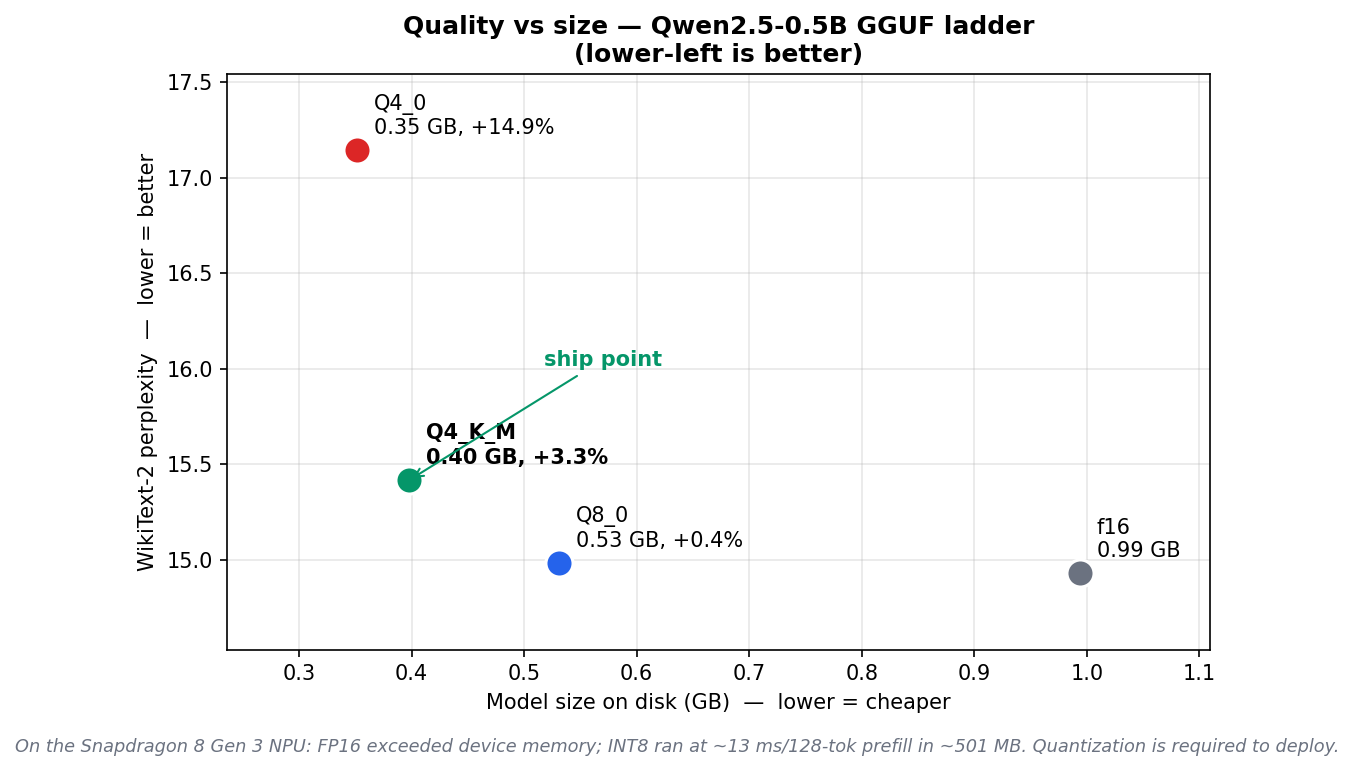

In [45]:
from IPython.display import Image
Image("results/pareto.png")